# 一、Auto-Encoder

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
from PIL import Image

data_set = datasets.MNIST(root='./.data', train=True, transform=transforms.ToTensor(), download=True)
print(data_set.data.shape)

# img, label = data_set[0]
# plt.imshow(img.squeeze(), cmap="gray")
# plt.axis("off")
# plt.show()


torch.Size([60000, 28, 28])


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /Users/xiangqi/.netrc
wandb: setting up run c9wqno6j
wandb: Tracking run with wandb version 0.30.0
wandb: Run data is saved locally in /Users/xiangqi/PycharmProjects/Fundamentals/MachineLearning/encoder/wandb/run-20260911_015342-c9wqno6j
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run embed=2-layer=3-hidden=32
wandb: ⭐️ View project at https://wandb.ai/xiangqi1229-uestc/mnist-autoencoder
wandb: 🚀 View run at https://wandb.ai/xiangqi1229-uestc/mnist-autoencoder/runs/c9wqno6j


0 100 0.0761258527636528 0.07729367166757584
0 200 0.06697456538677216 0.0693826675415039
0 300 0.07132402062416077 0.06687454879283905
0 400 0.0647471621632576 0.06497101485729218
0 500 0.06514928489923477 0.0621284544467926
1 600 0.05697188526391983 0.06041349098086357
1 700 0.05823815241456032 0.059239983558654785
1 800 0.05664950609207153 0.05839123576879501
1 900 0.05744576454162598 0.05789199471473694
1 1000 0.0605577751994133 0.05732047185301781
2 1100 0.056774090975522995 0.05690434202551842
2 1200 0.054543811827898026 0.05653214082121849
2 1300 0.05249762535095215 0.05621865764260292
2 1400 0.05746825039386749 0.0559176504611969
2 1500 0.05370248109102249 0.055559754371643066
2 1600 0.05589437857270241 0.05523281544446945
3 1700 0.05884050577878952 0.0550340972840786
3 1800 0.05976923555135727 0.05475251004099846
3 1900 0.051922593265771866 0.05451786518096924
3 2000 0.05824305862188339 0.054231543093919754
3 2100 0.05334259197115898 0.05391640588641167
4 2200 0.05760503187775

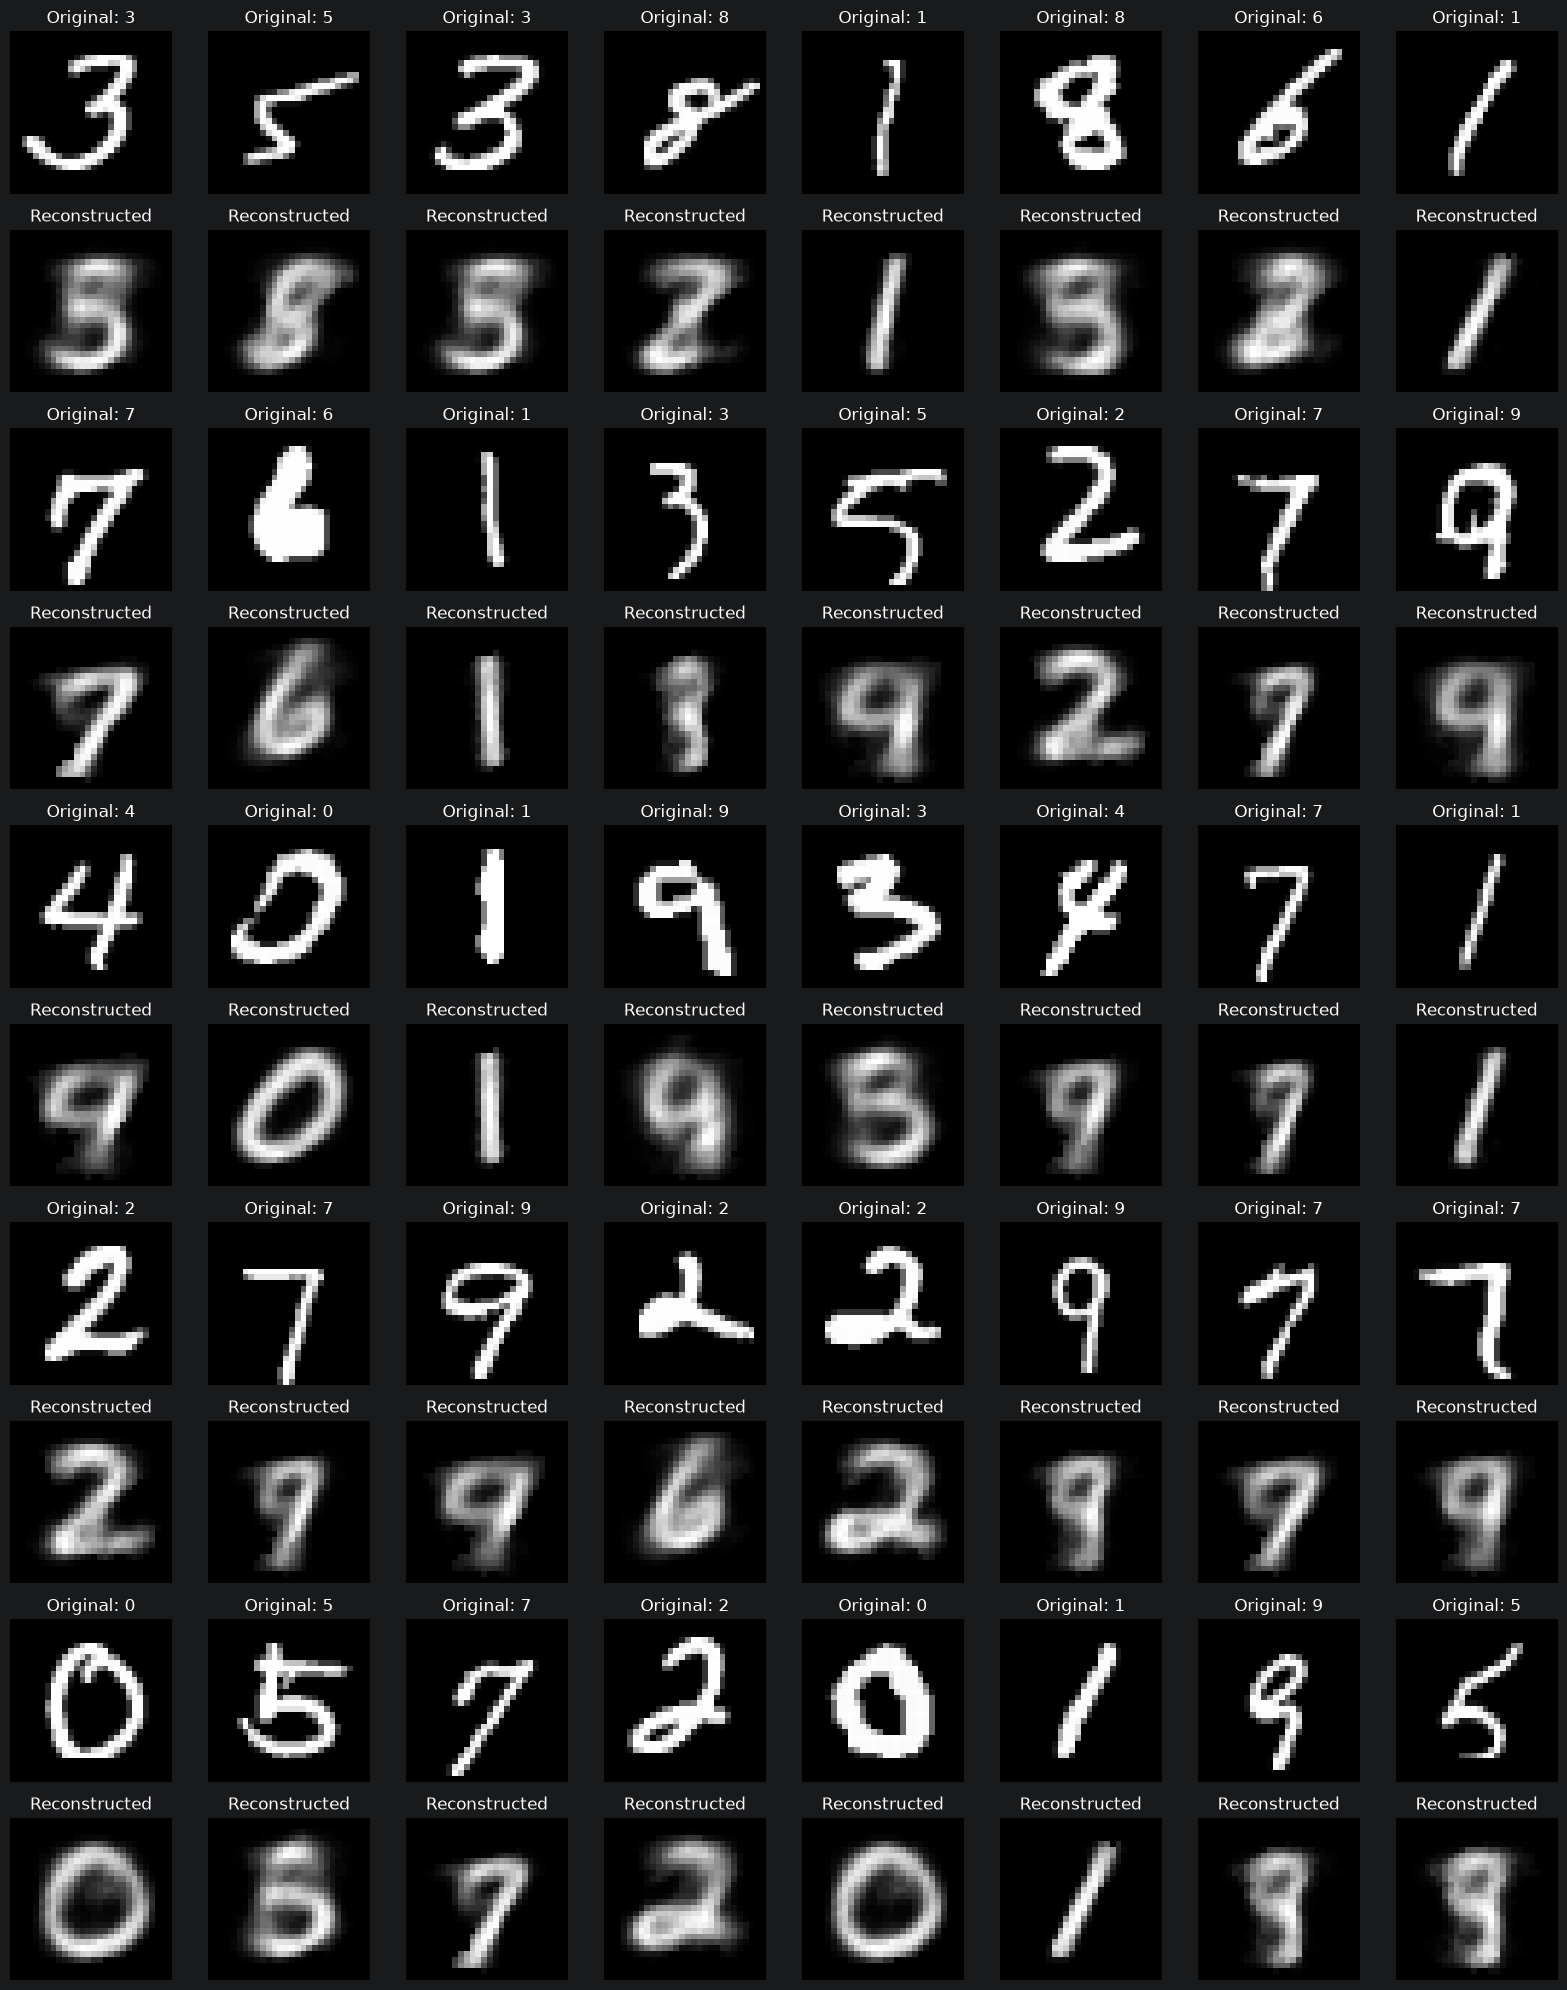

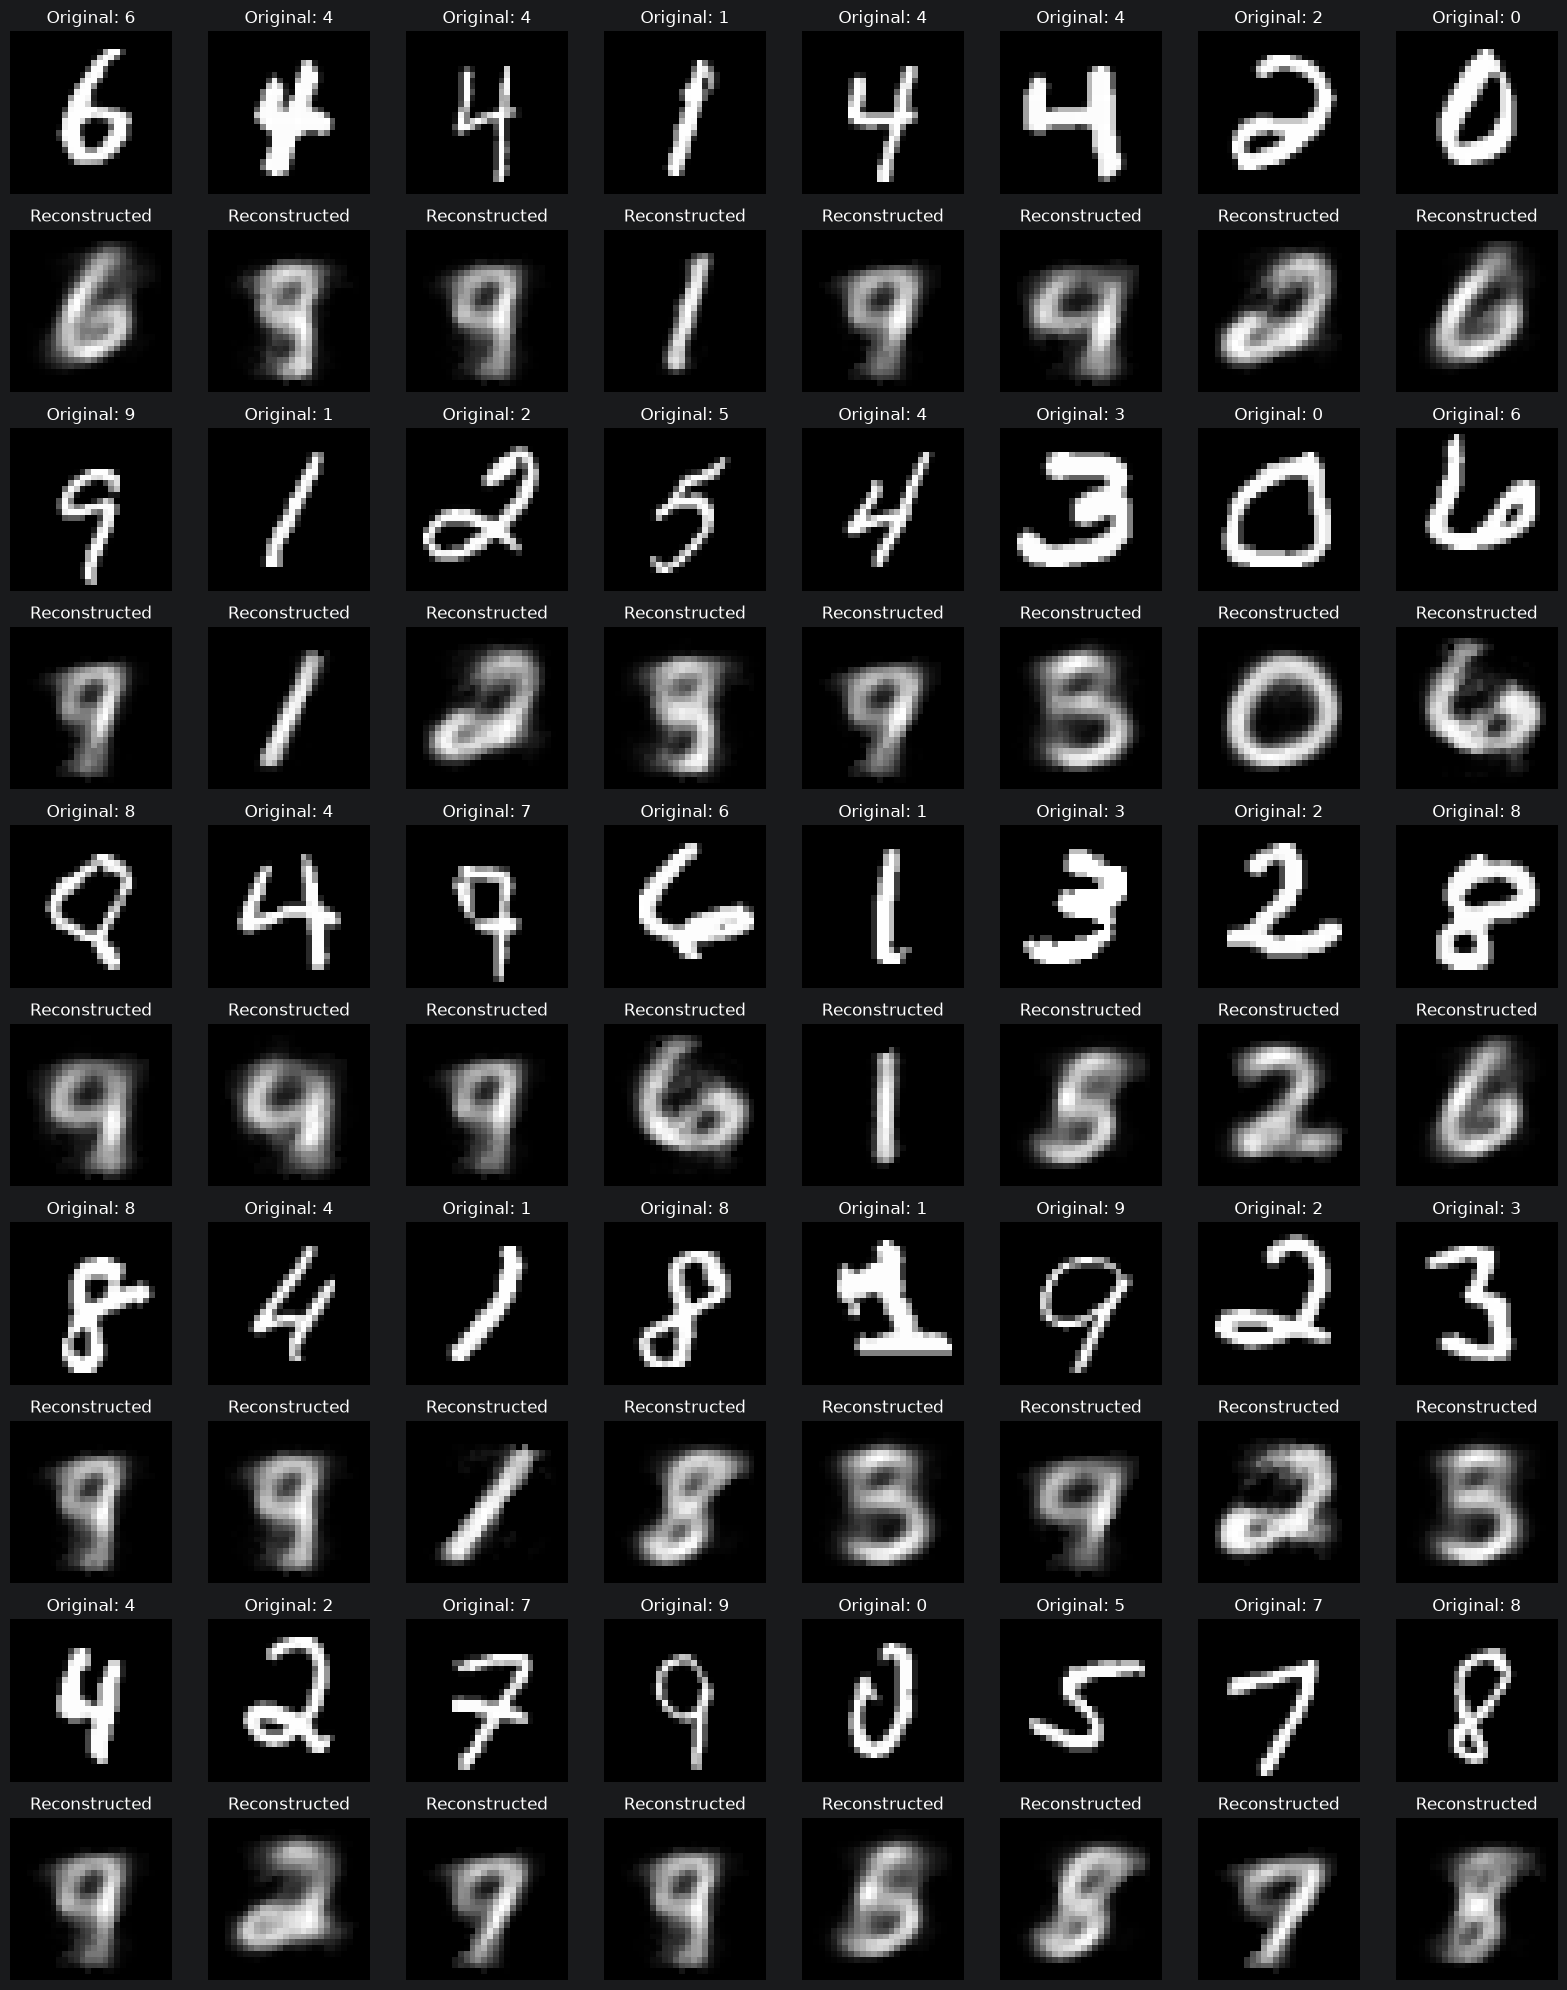

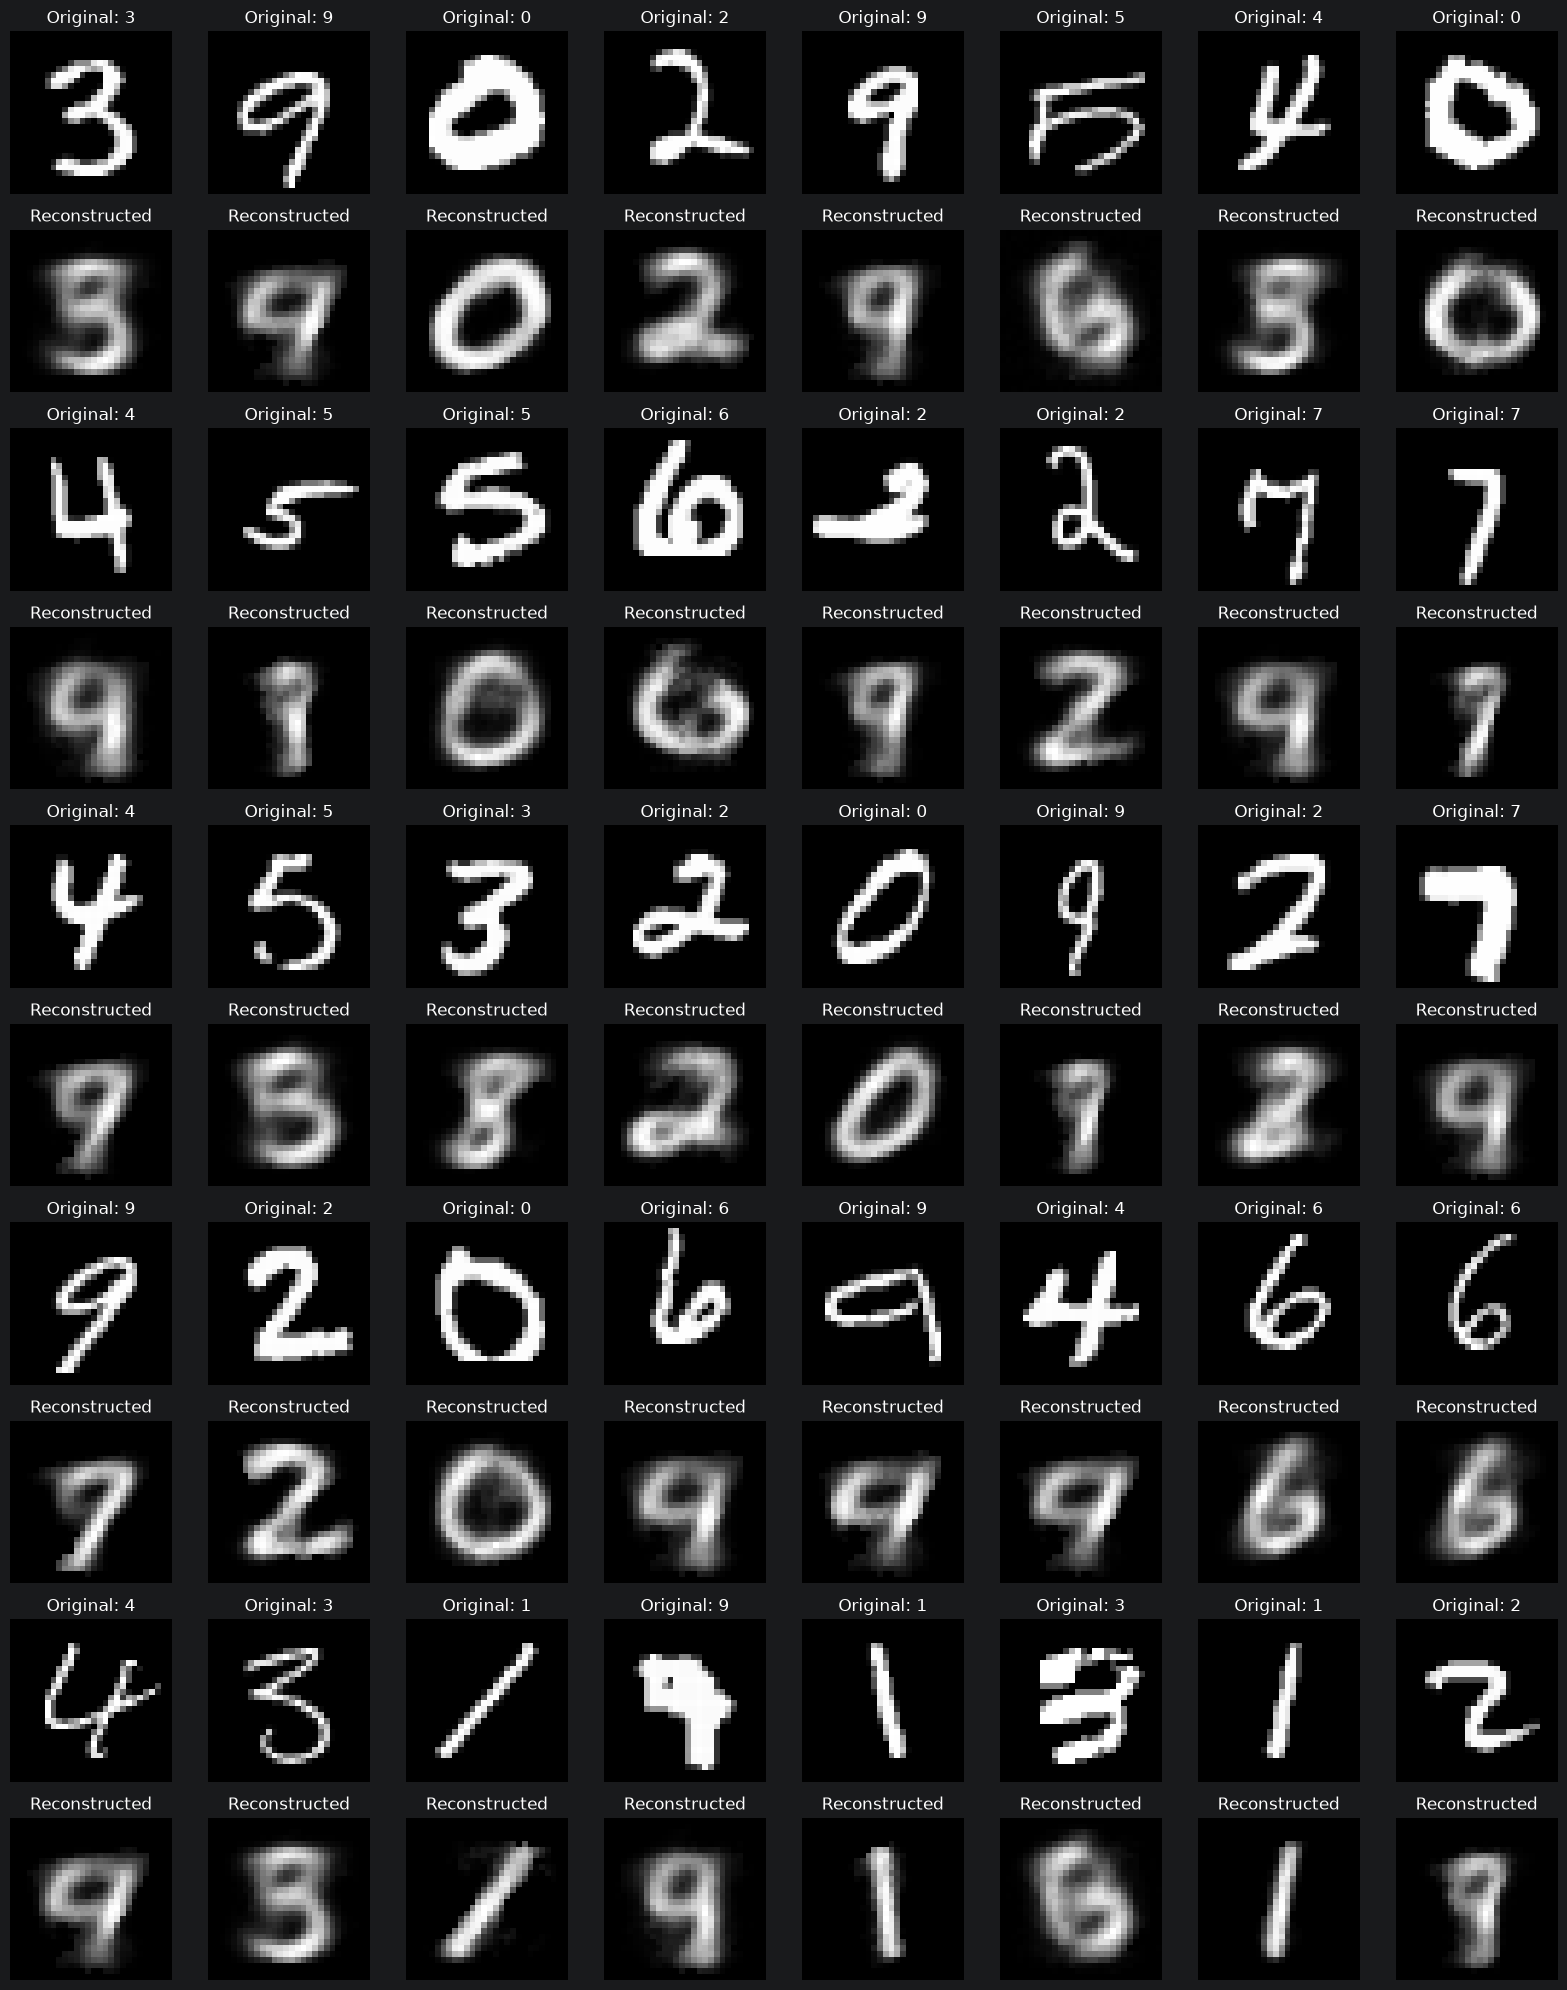

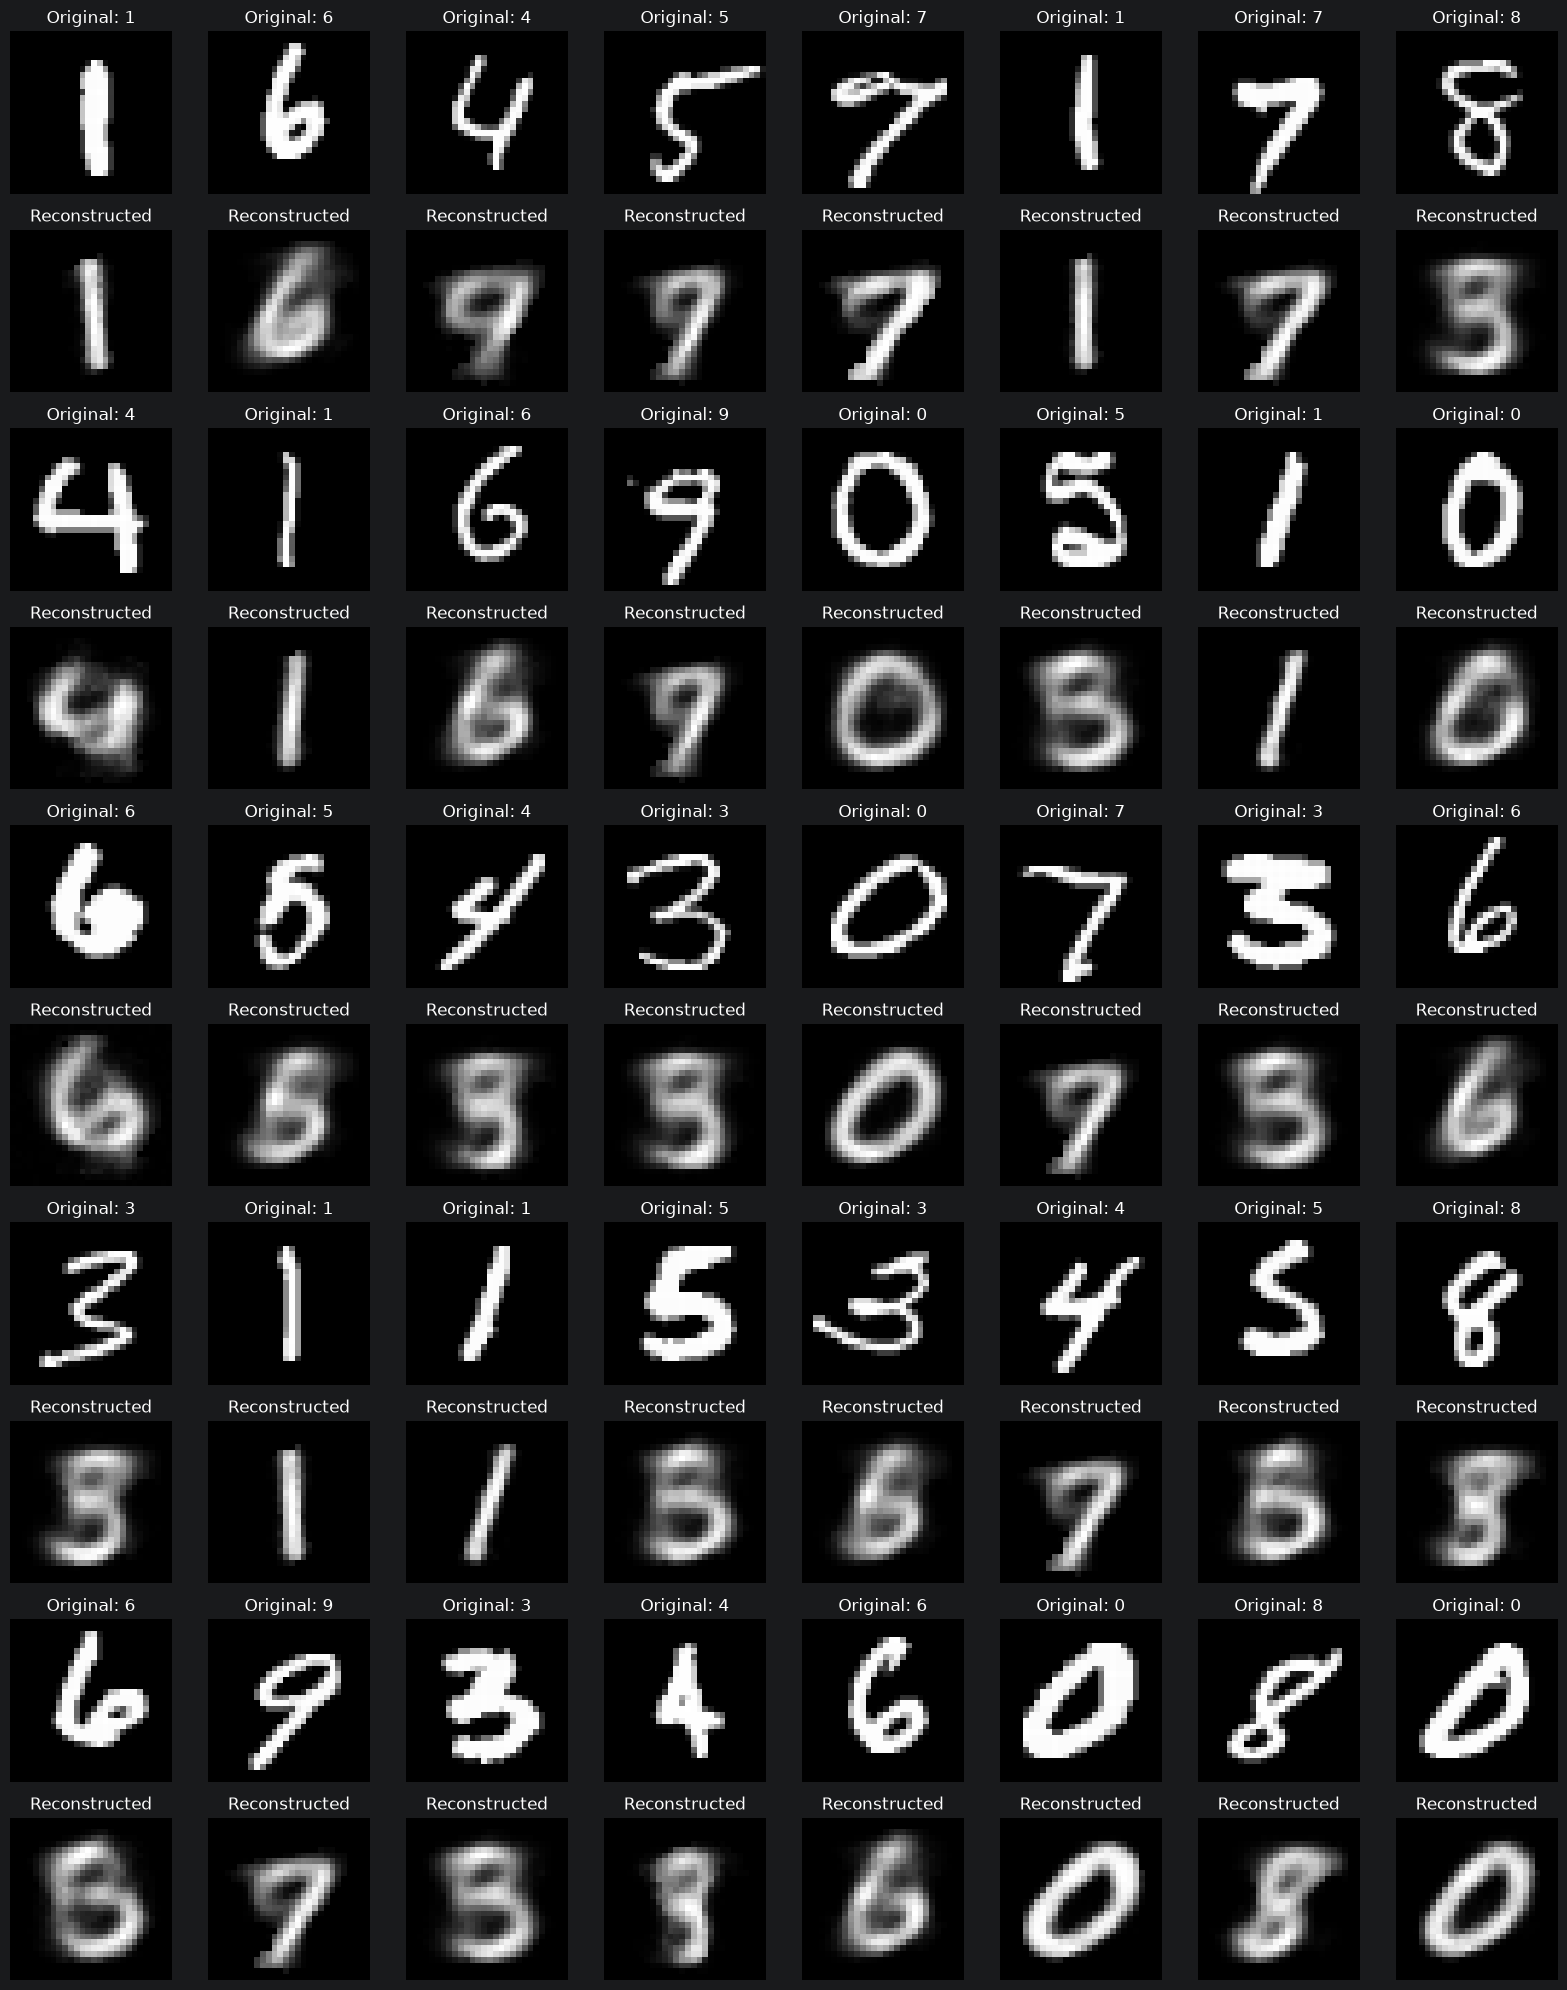

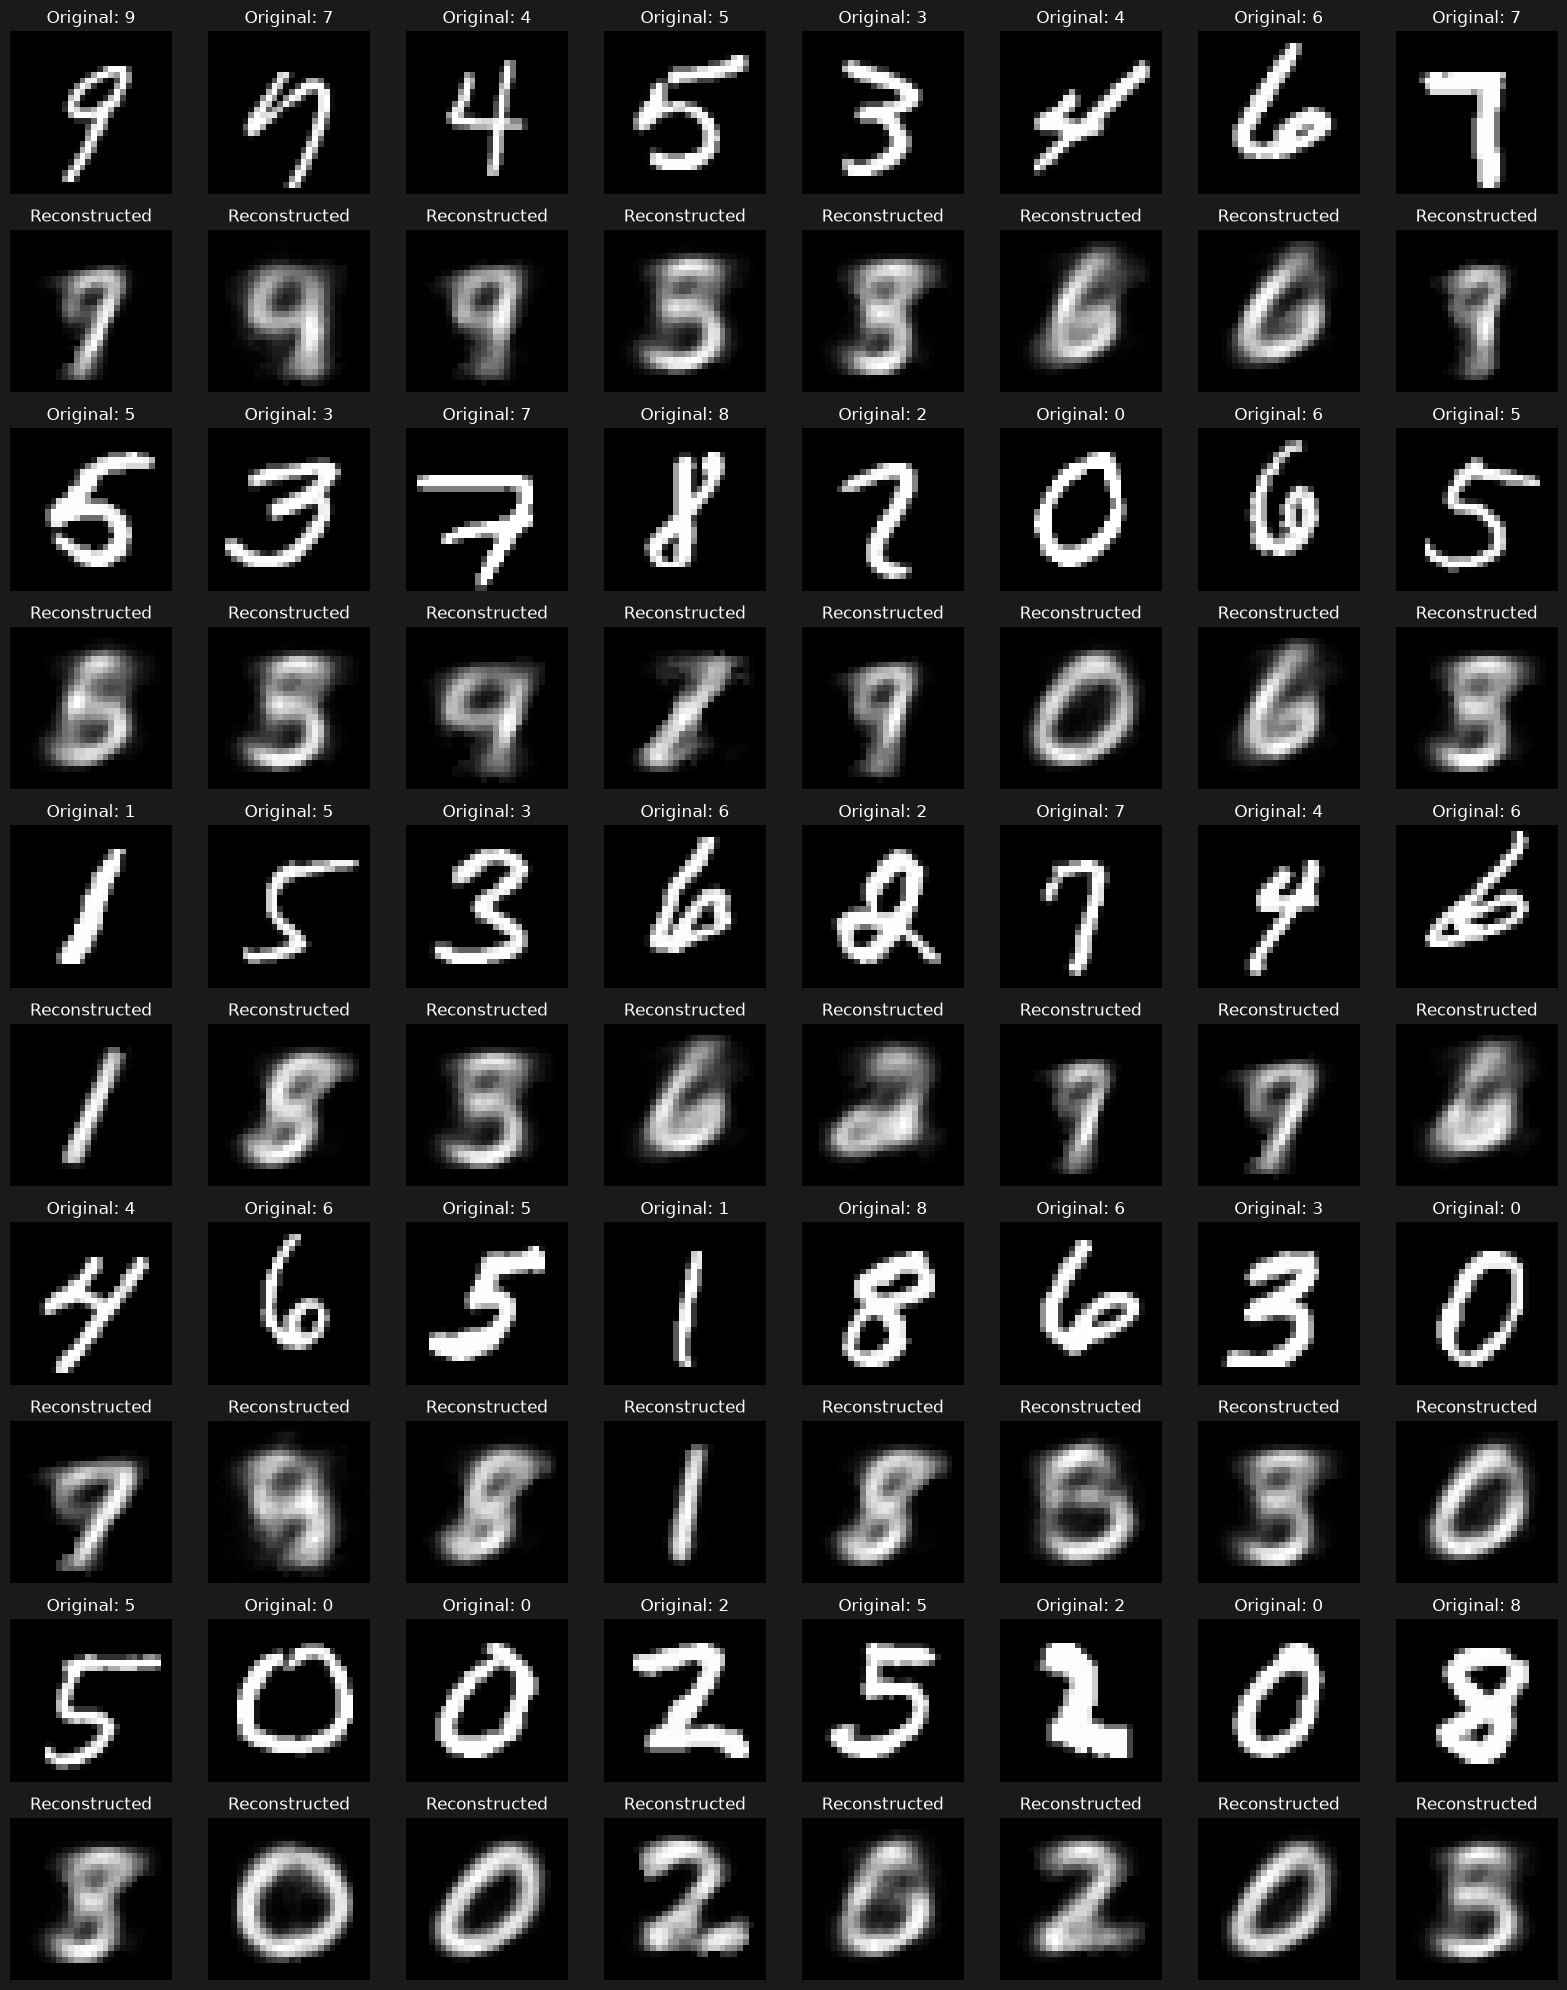

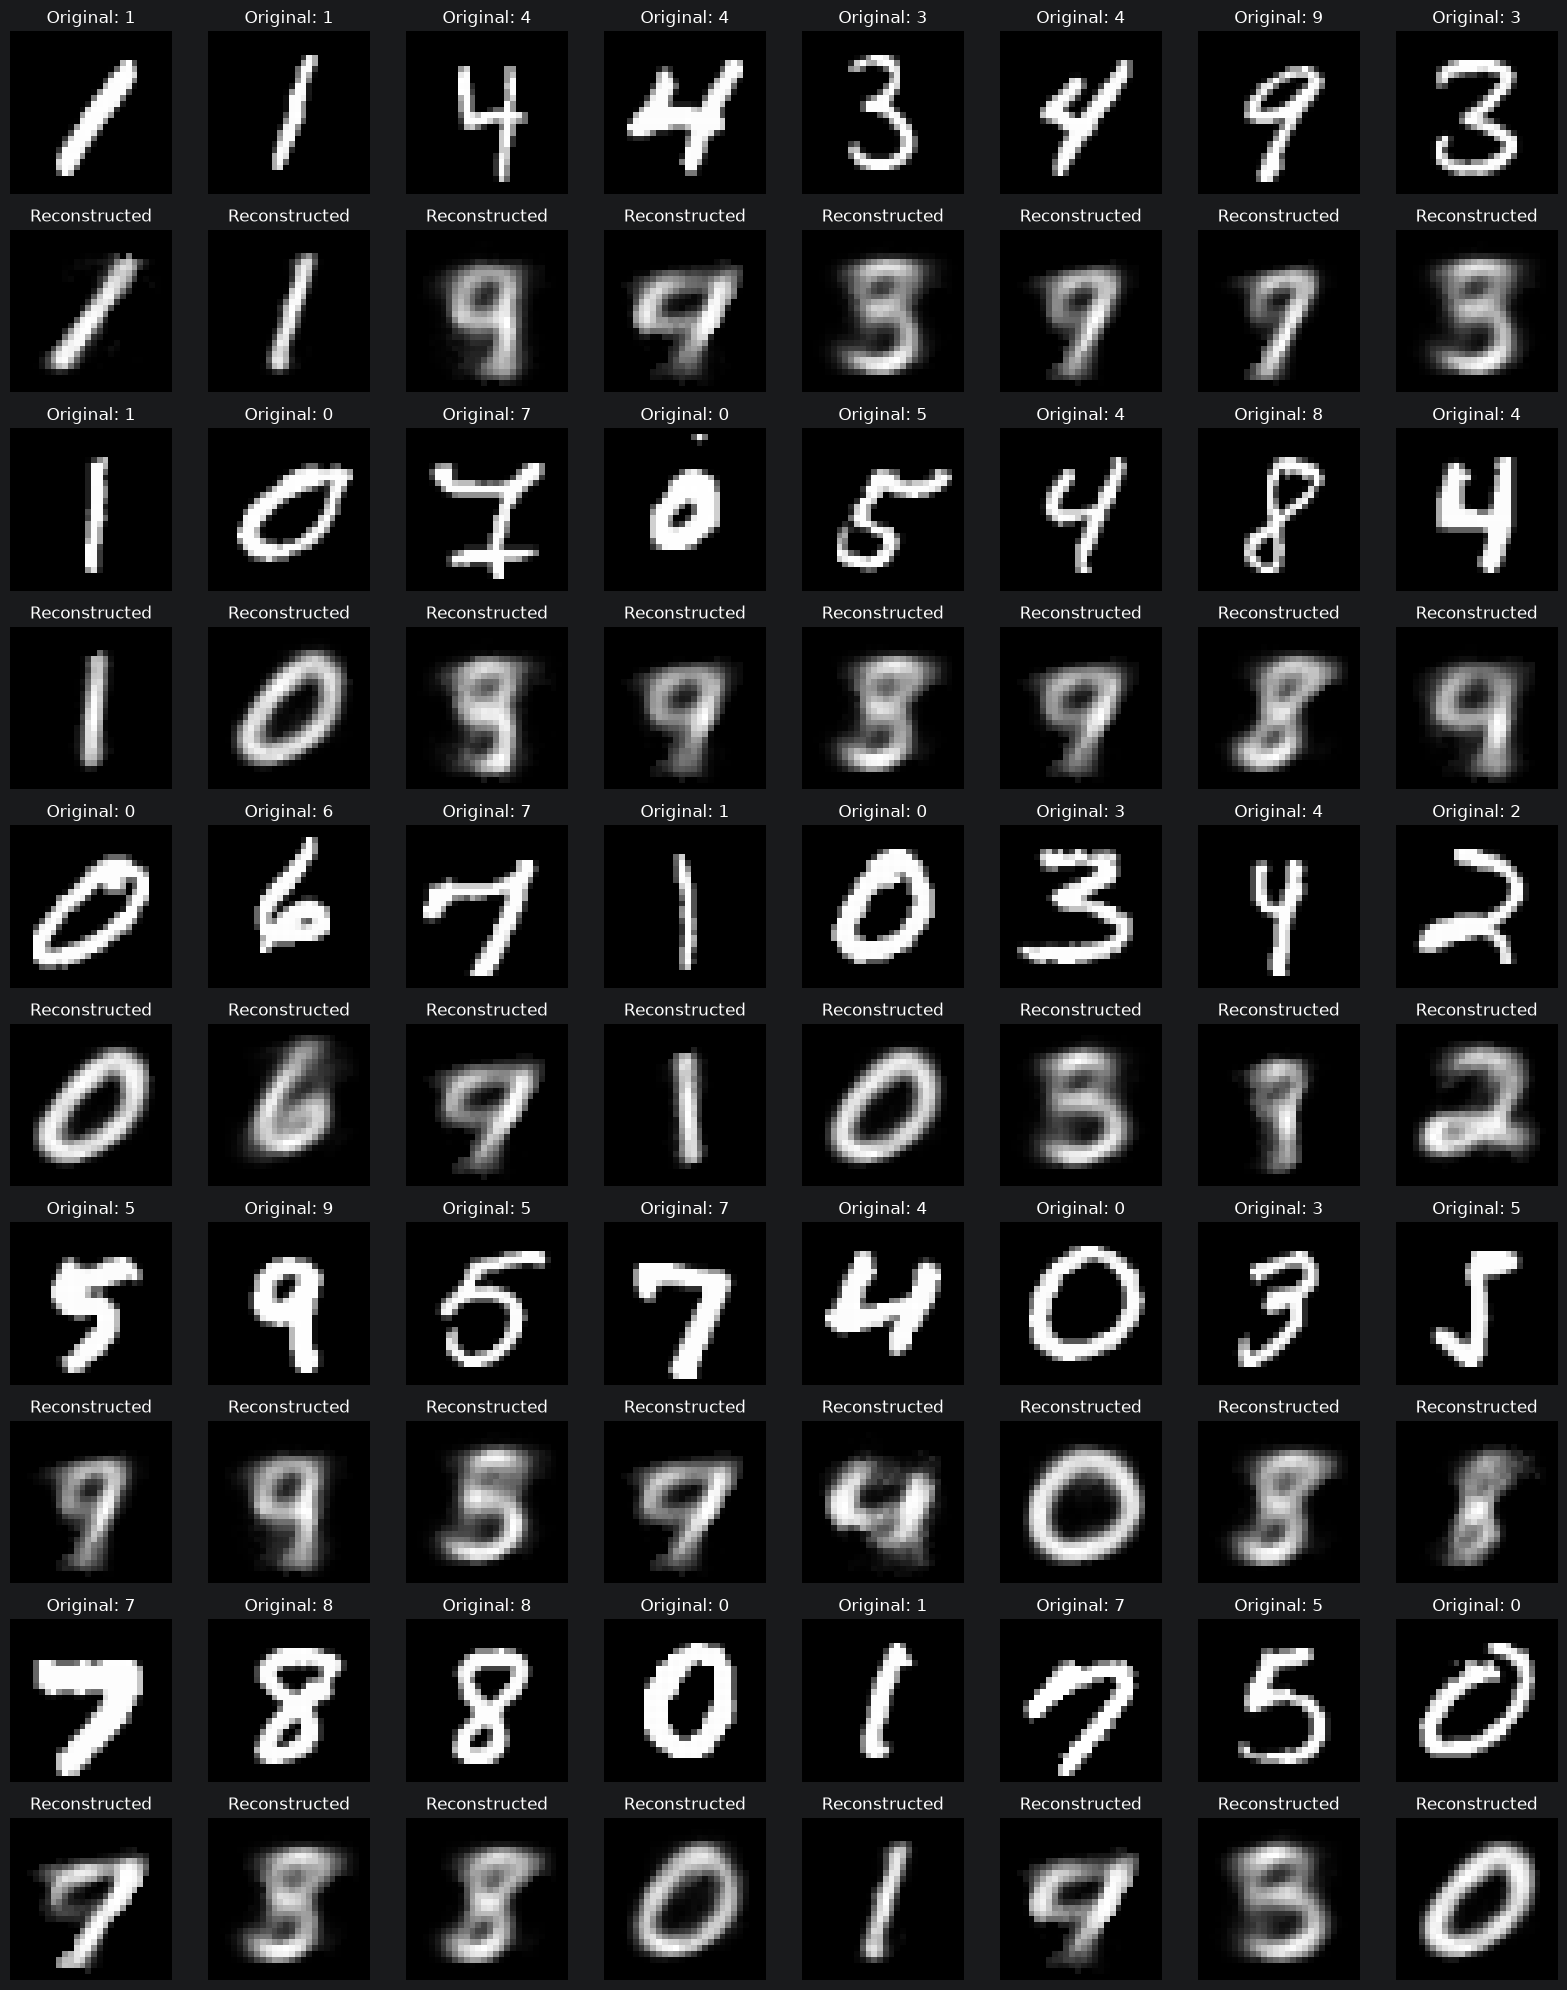

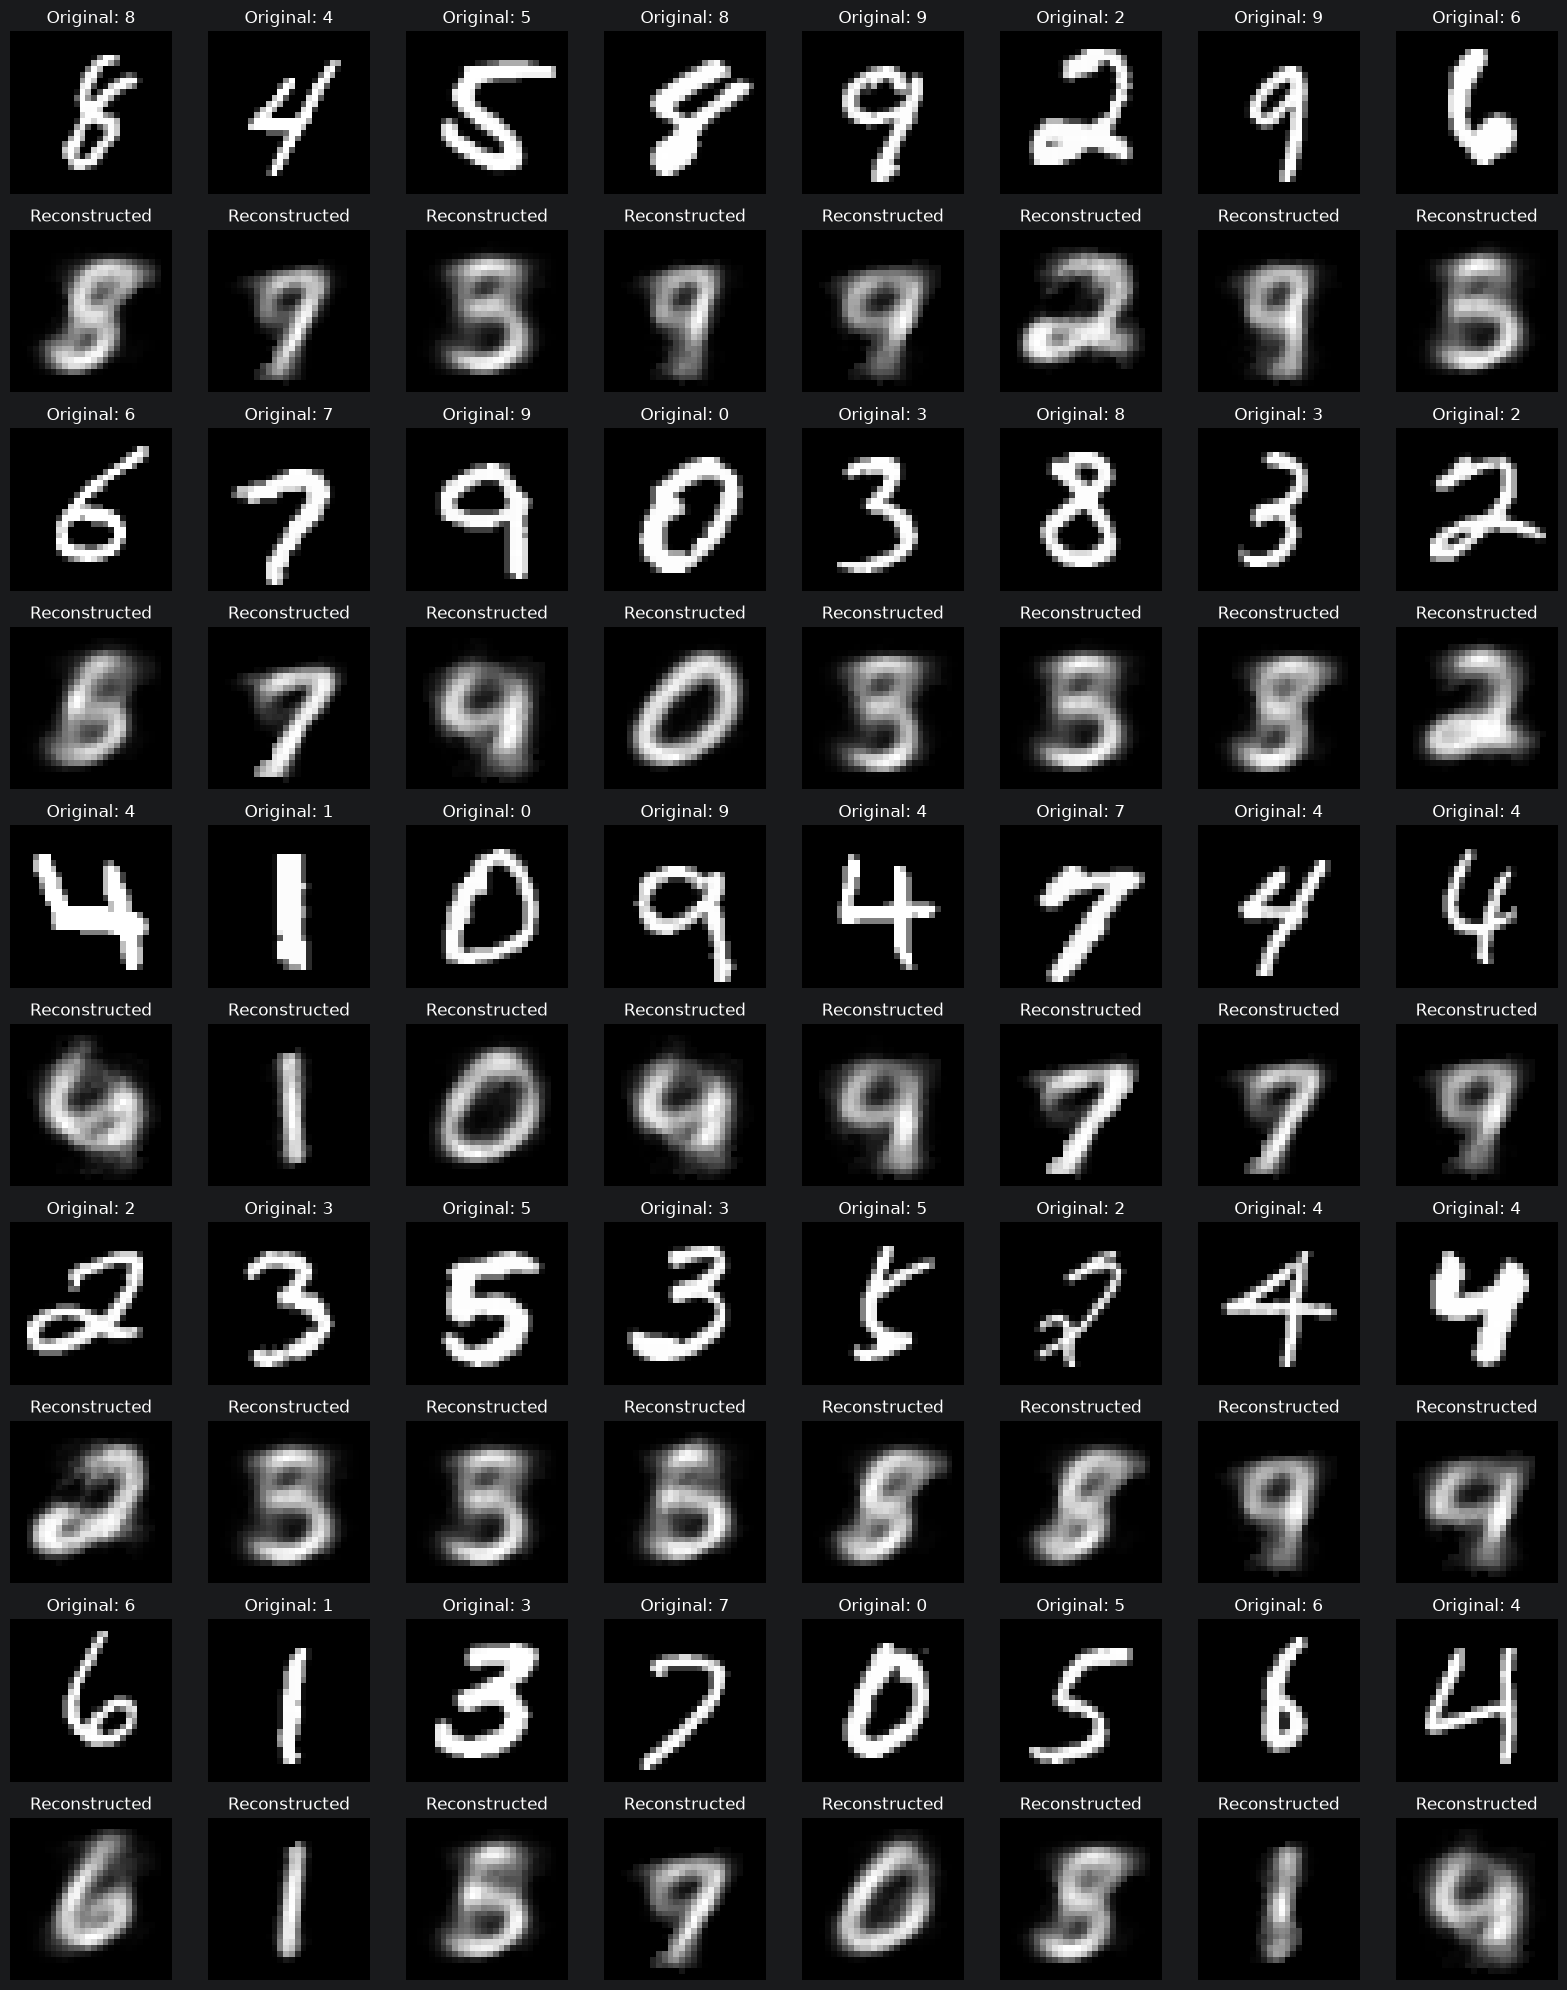

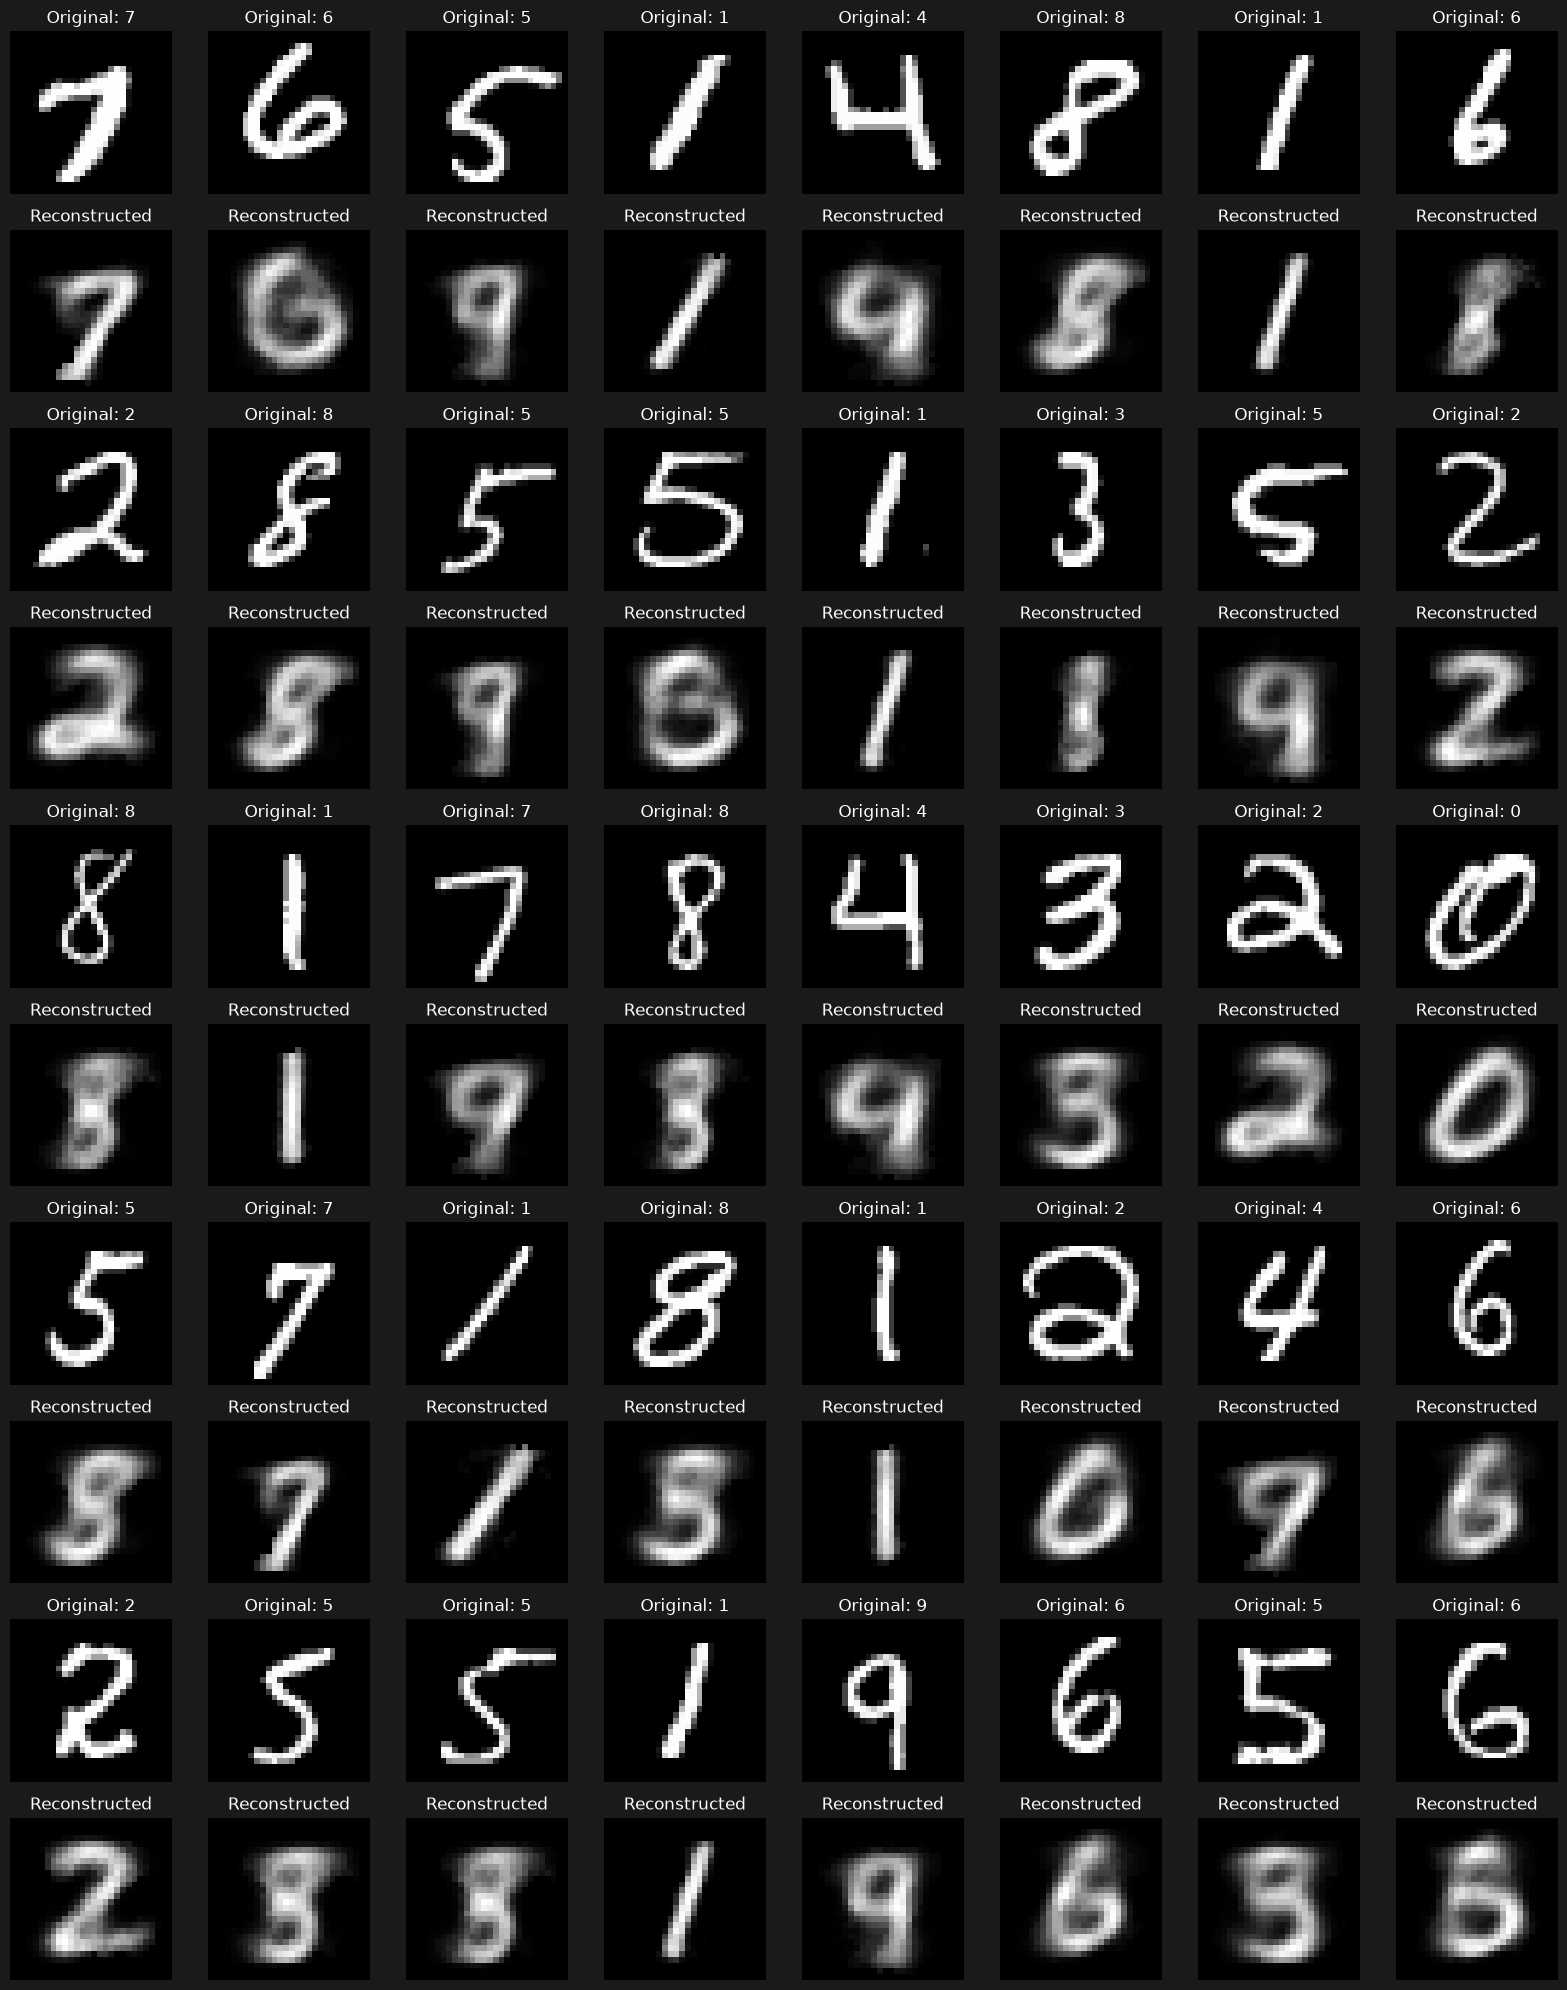

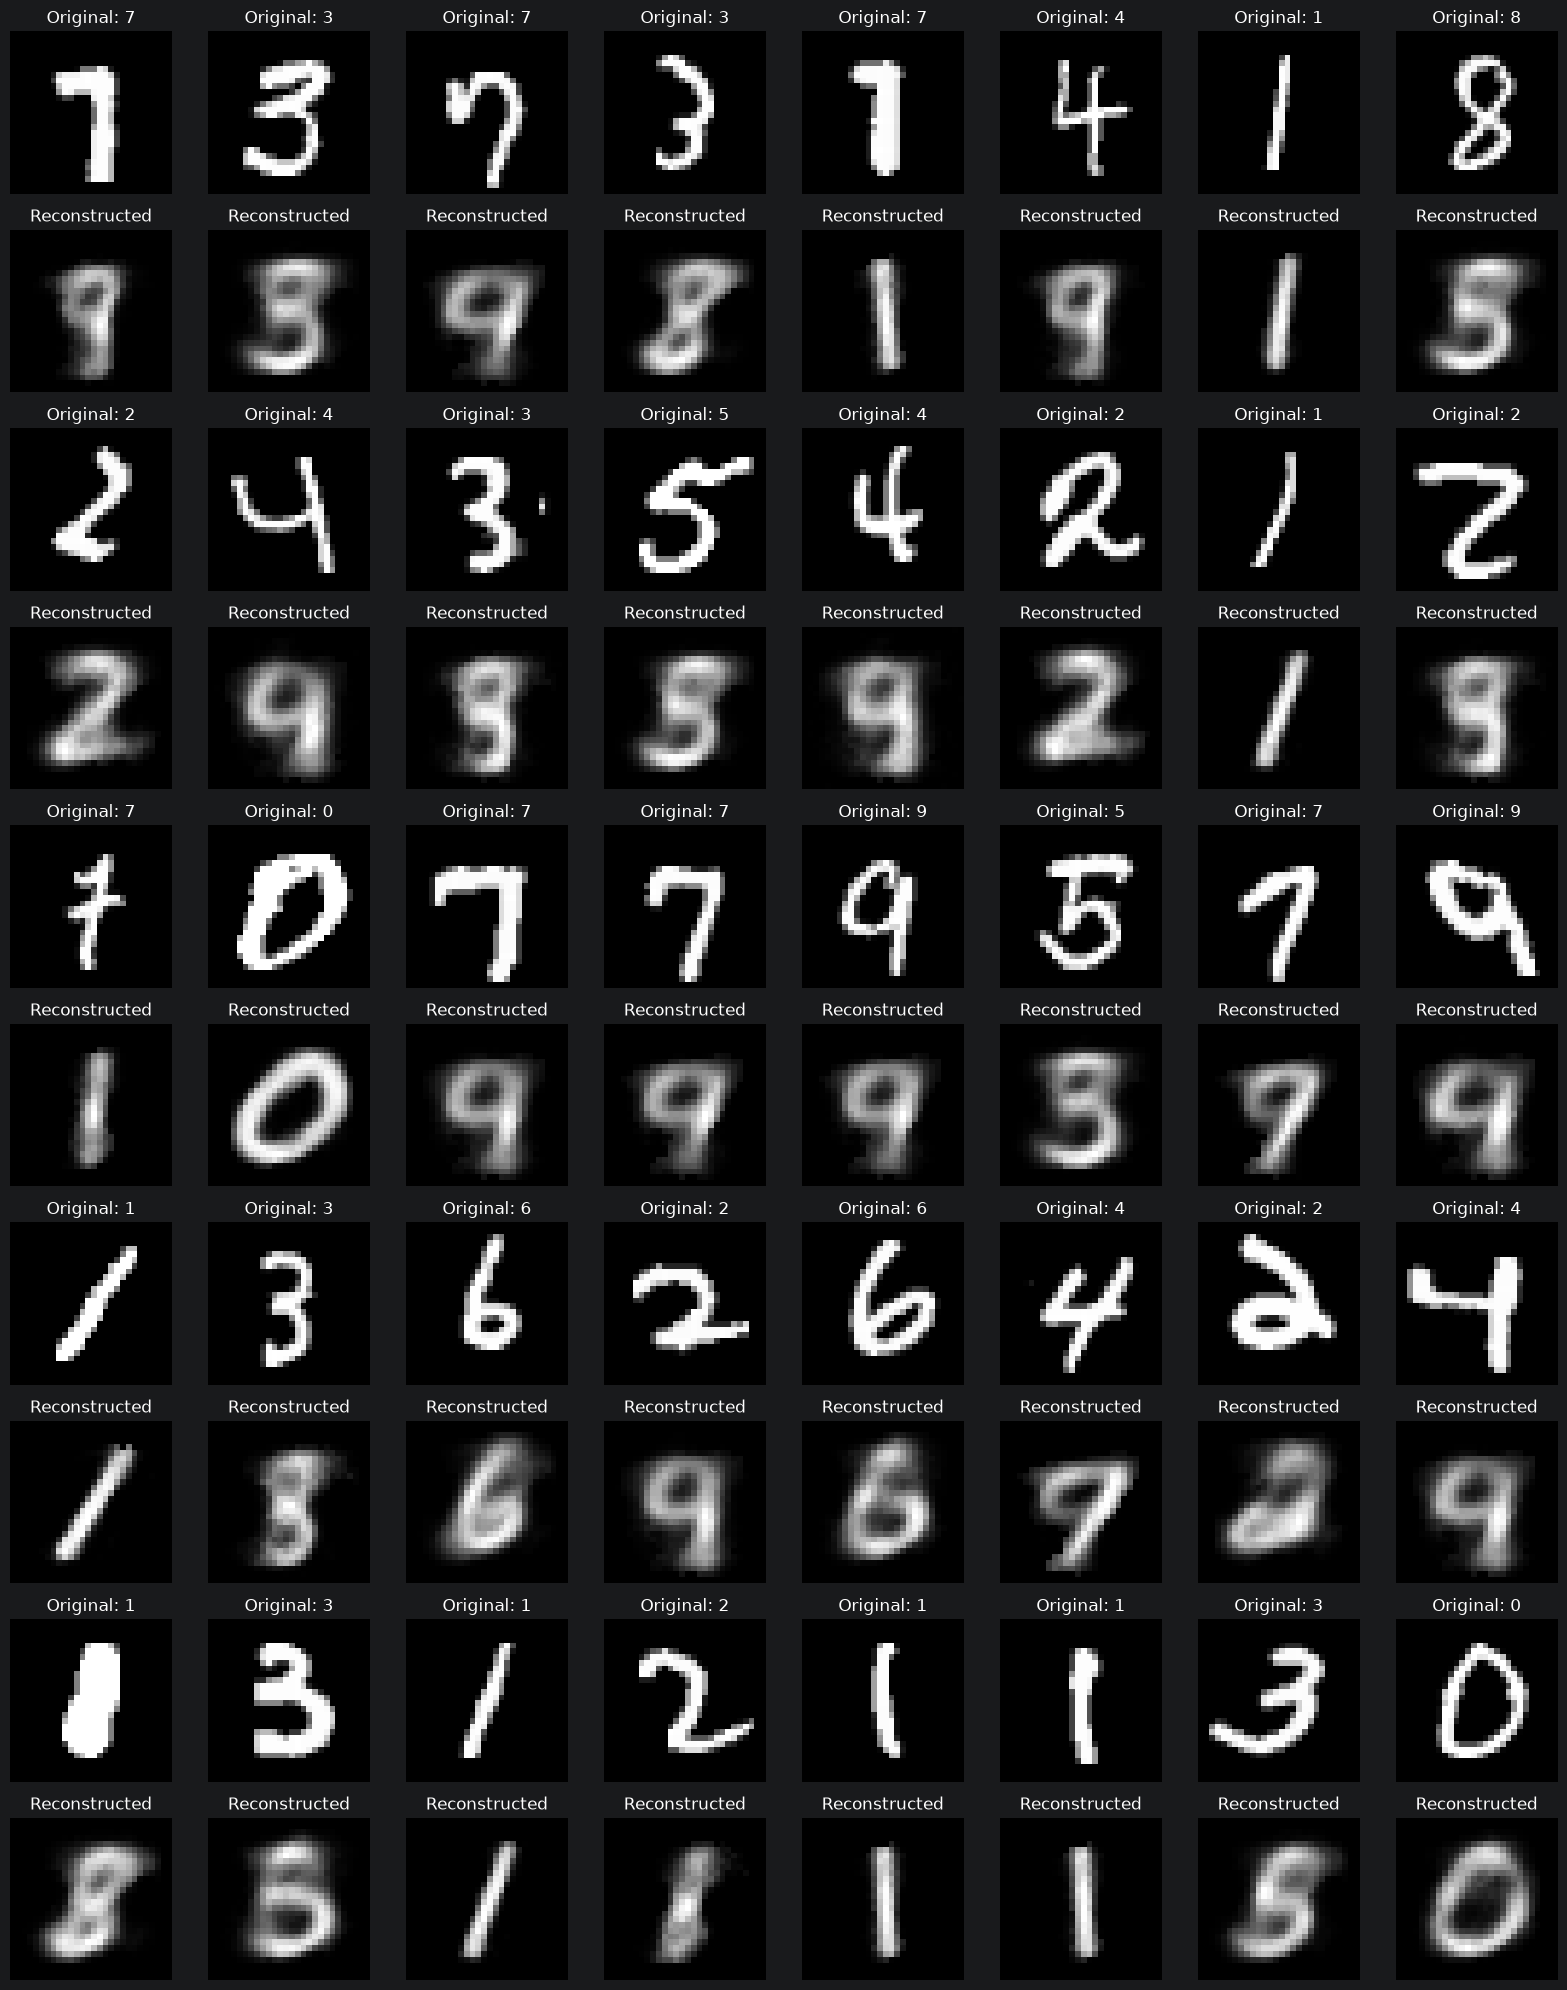

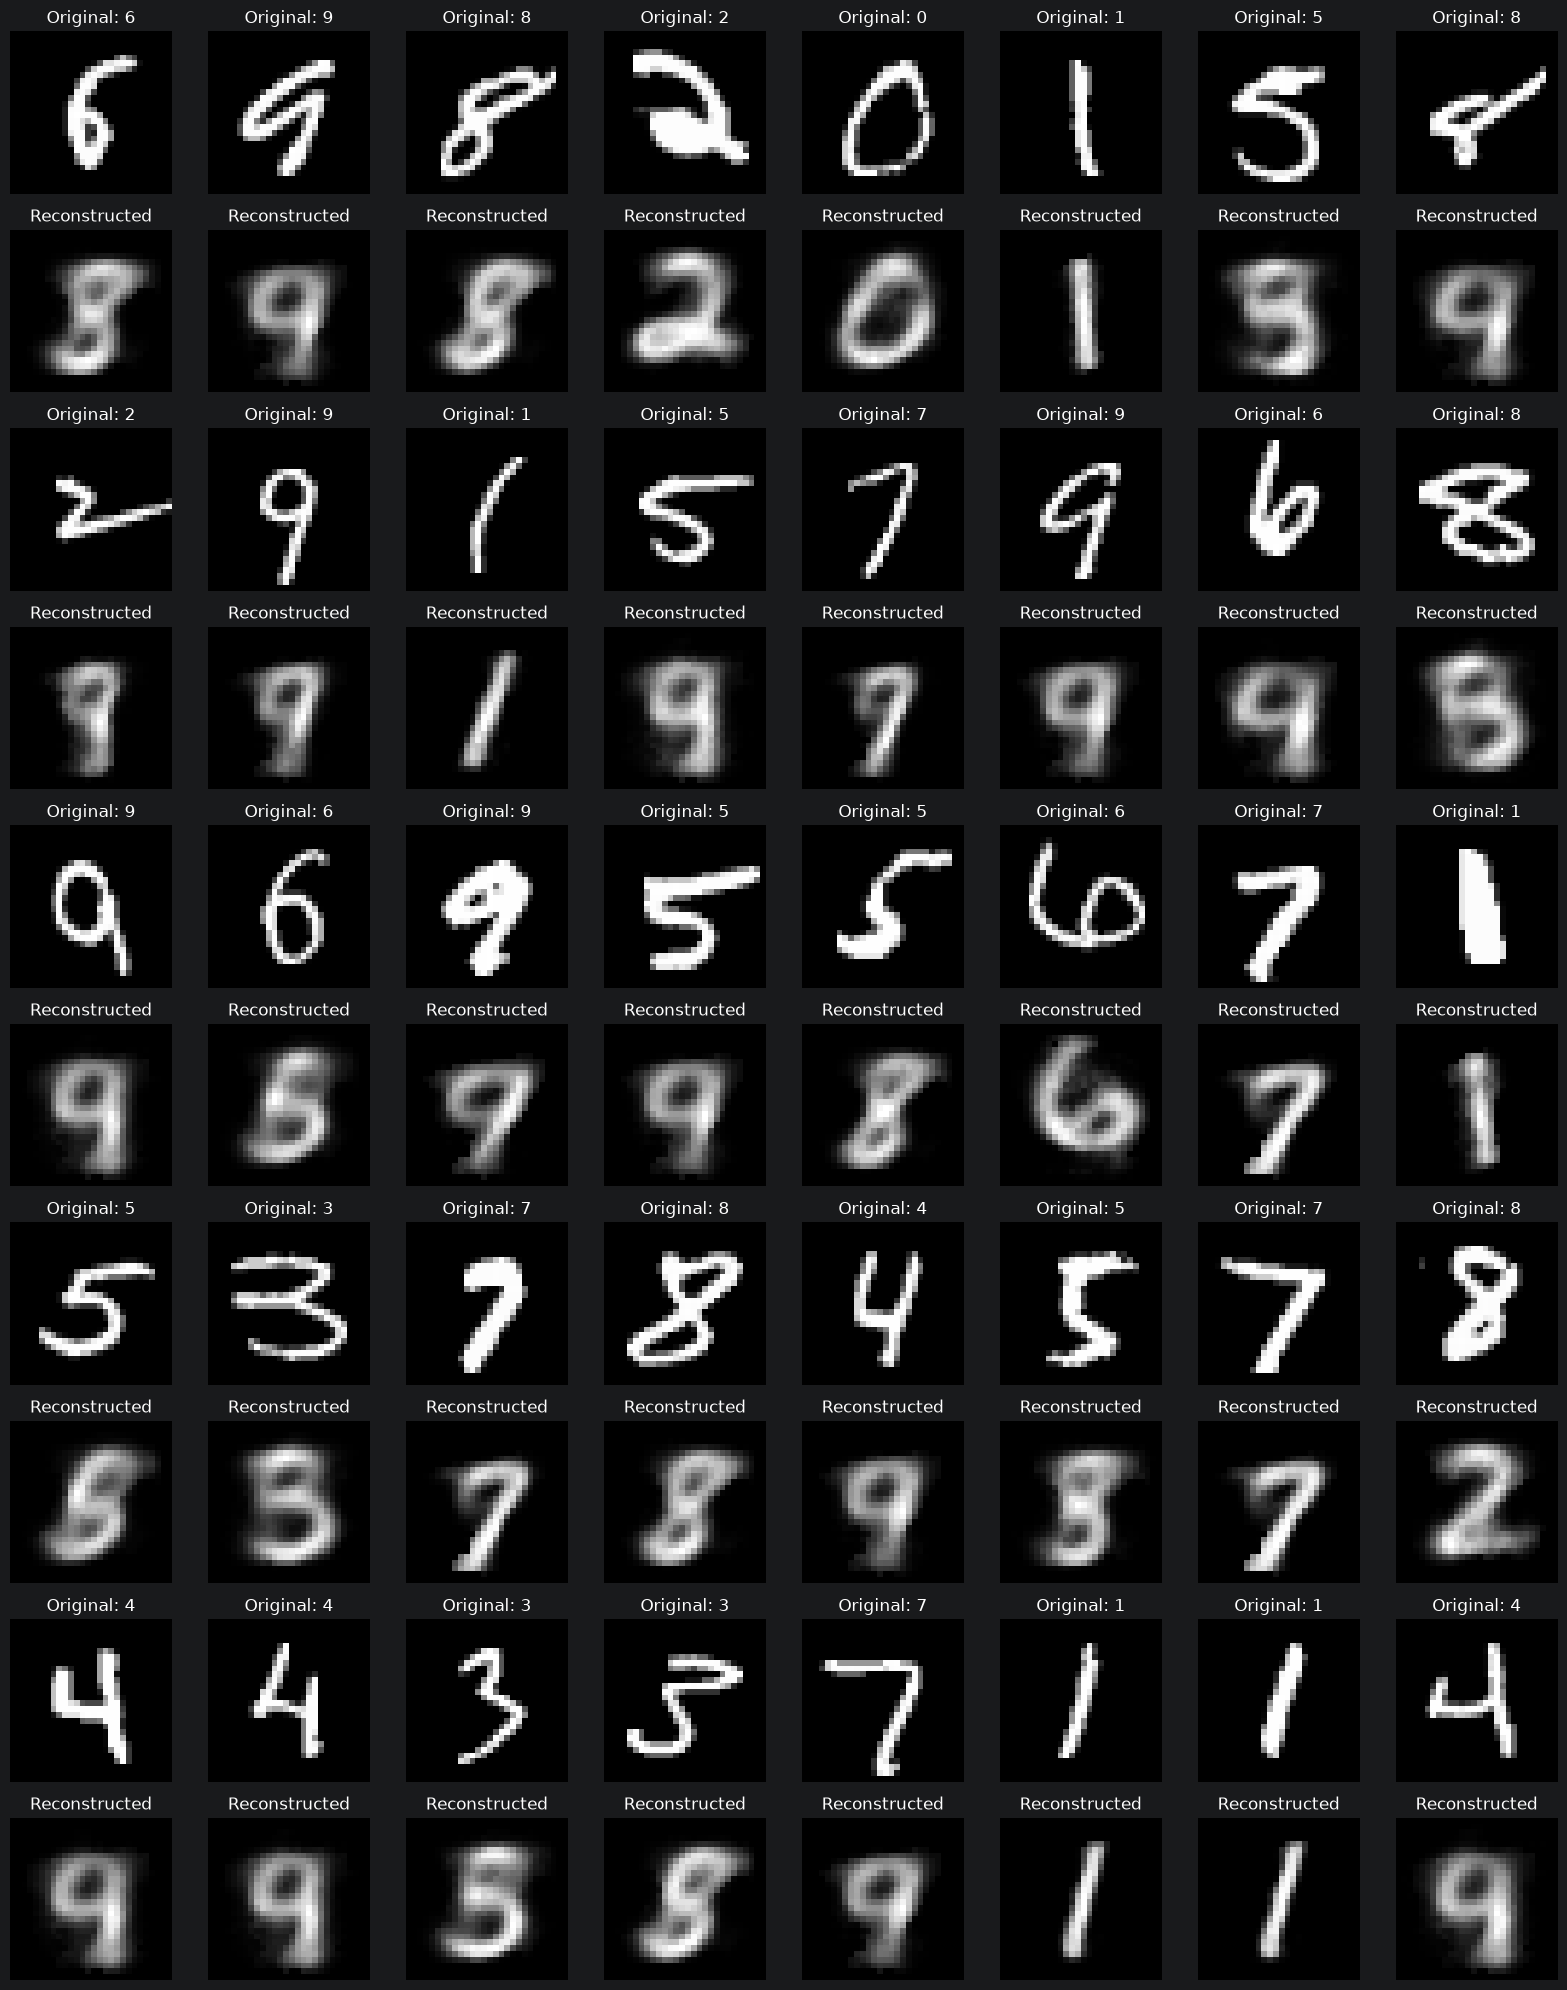

wandb: uploading media/images/reconstruction/6_10805_05621fb4f57b359e7300.png; uploading media/images/reconstruction/7_10806_c4e32da8d404ca0032ae.png; uploading media/images/reconstruction/8_10807_042b1674c670181e3b90.png; updating run metadata
wandb: updating run metadata
wandb: uploading media/images/reconstruction/10_10809_39a6a22a3282d610d323.png; uploading wandb-summary.json; uploading config.yaml; uploading media/images/reconstruction/9_10808_4100b7822f98da1c236e.png
wandb: uploading media/images/reconstruction/9_10808_4100b7822f98da1c236e.png
wandb: uploading history steps 114-116, summary
wandb: 
wandb: Run history:
wandb:      epoch ▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▄▄▅▅▅▆▆▇▇▇▇▇▇█████
wandb: train/loss █▆▇▄▅▄▄▄▃▃▃▃▂▃▃▃▃▃▃▃▂▂▂▃▂▂▂▂▂▁▃▂▂▂▂▂▂▂▁▂
wandb:   val/loss █▆▆▅▄▄▄▄▃▃▃▃▃▃▃▂▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁
wandb: 
wandb: Run summary:
wandb:      epoch 19
wandb: train/loss 0.04536
wandb:   val/loss 0.04503
wandb: 
wandb: 🚀 View run embed=2-layer=3-hidden=32 at: https://wandb.ai/xiangqi1229-uestc

In [4]:
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import wandb
import matplotlib.pyplot as plt
import os

wandb.login(key=os.environ["WANDB_API_KEY"])
torch.manual_seed(42)


class Encoder(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_linear=1):
        super(Encoder, self).__init__()
        self.fc_in = torch.nn.Linear(input_size, hidden_size)
        self.fc_out = torch.nn.Linear(hidden_size, output_size)
        self.n_liner = torch.nn.ModuleList([
            torch.nn.Linear(hidden_size, hidden_size)
            for _ in range(n_linear)
        ])

    def forward(self, x):
        x = F.relu(self.fc_in(x))
        for liner in self.n_liner:
            x = F.relu(liner(x))
        x = self.fc_out(x)
        return x


class Decoder(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_linear=1):
        super(Decoder, self).__init__()
        self.fc_in = torch.nn.Linear(input_size, hidden_size)
        self.fc_out = torch.nn.Linear(hidden_size, output_size)
        self.n_liner = torch.nn.ModuleList([
            torch.nn.Linear(hidden_size, hidden_size)
            for _ in range(n_linear)
        ])

    def forward(self, x):
        x = F.relu(self.fc_in(x))
        for liner in self.n_liner:
            x = F.relu(liner(x))
        x = torch.sigmoid(self.fc_out(x))
        return x


embed_size = 2
n_fc = 1
mlp_input_size = data_set.data.shape[-1] * data_set.data.shape[-2]
hidden_size = 32
lr = 0.0005
epochs = 20
bs = 100
log_interval = 100

exps = {
    "mlp": {
        "encoder": Encoder(mlp_input_size, hidden_size, embed_size, n_fc),
        "decoder": Decoder(embed_size, hidden_size, mlp_input_size, n_fc),
    }
}

train_set, test_set = random_split(data_set, [0.9, 0.1])

data_loader = DataLoader(
    train_set,
    batch_size=bs,
    shuffle=True
)

test_loader = DataLoader(
    test_set,
    batch_size=len(test_set),
    shuffle=False
)


for name, exp in exps.items():

    with wandb.init(
        project="mnist-autoencoder",
        name=f"embed={embed_size}-layer={n_fc+2}-hidden={hidden_size}",
        config={
            "embed_size": embed_size,
            "hidden_size": hidden_size,
            "n_fc": n_fc,
            "lr": lr,
            "batch_size": bs,
            "epochs": epochs,
            "model": name,
        }
    ) as run:

        encoder = exp["encoder"]
        decoder = exp["decoder"]

        params = list(encoder.parameters()) + list(decoder.parameters())

        optimizer = torch.optim.Adam(
            params,
            lr=lr
        )

        global_step = 0

        for ep in range(epochs):

            encoder.train()
            decoder.train()

            for step, data in enumerate(data_loader):

                optimizer.zero_grad()

                imgs, labels = data
                imgs = imgs.reshape(imgs.shape[0], -1)

                embed = encoder(imgs)
                origin = decoder(embed)

                loss = F.mse_loss(origin, imgs)

                loss.backward()
                optimizer.step()

                global_step += 1

                if global_step % log_interval == 0:

                    encoder.eval()
                    decoder.eval()

                    with torch.no_grad():
                        imgs, labels = next(iter(test_loader))
                        imgs = imgs.reshape(imgs.shape[0], -1)

                        embed = encoder(imgs)
                        origin = decoder(embed)

                        test_loss = F.mse_loss(origin, imgs)

                    print(
                        ep,
                        global_step,
                        loss.item(),
                        test_loss.item()
                    )

                    run.log(
                        {
                            "train/loss": loss.item(),
                            "val/loss": test_loss.item(),
                            "epoch": ep,
                        },
                        step=global_step
                    )

                    encoder.train()
                    decoder.train()

        encoder.eval()
        decoder.eval()

        sample_generator = torch.Generator().manual_seed(42)

        num_figures = 10
        num_images = 40
        num_cols = 8
        num_rows = (num_images + num_cols - 1) // num_cols

        indices = torch.randperm(
            len(test_set),
            generator=sample_generator
        )[:num_figures * num_images]

        for fig_idx in range(num_figures):
            fig = plt.figure(figsize=(16, 4 * num_rows))

            start = fig_idx * num_images
            end = start + num_images
            figure_indices = indices[start:end]

            axes = fig.subplots(num_rows * 2, num_cols)

            for i, idx in enumerate(figure_indices):
                img, label = test_set[idx]

                img_flat = img.reshape(1, -1)

                with torch.no_grad():
                    reconstruct = decoder(encoder(img_flat))

                reconstruct = reconstruct.reshape(28, 28)

                row = i // num_cols
                col = i % num_cols

                axes[row * 2, col].imshow(img.squeeze(), cmap="gray")
                axes[row * 2, col].set_title(f"Original: {label}")
                axes[row * 2, col].axis("off")

                axes[row * 2 + 1, col].imshow(reconstruct, cmap="gray")
                axes[row * 2 + 1, col].set_title("Reconstructed")
                axes[row * 2 + 1, col].axis("off")

            plt.tight_layout()

            run.log({
                f"reconstruction/{fig_idx + 1}": wandb.Image(fig)
            })

            plt.show()
            plt.close(fig)